In [46]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [47]:
df = pd.read_csv("../data/engineered_data.csv")

In [48]:
features = [
    "credit_limit",
    "num_cards_issued",
    "account_age",
    "pin_age",
    "years_to_expiry",
    "has_chip",
    "card_type",
    "card_on_dark_web",
    "card_brand_encoded"
]

In [50]:
features = [f for f in features if f in df.columns]
df = df[features]

In [51]:
X = df[features]

In [52]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [53]:
X_scaled[:5]

array([[ 0.77990113,  0.9535527 ,  1.39740131, -0.66120426,  0.34253046,
        -0.78661409,  0.        ,  1.1596176 ],
       [ 0.59122235,  0.9535527 , -0.44830648,  0.68182919,  0.34253046,
        -0.78661409,  0.        ,  1.1596176 ],
       [ 2.57336305,  0.9535527 ,  1.24359233,  2.36062101,  0.34253046,
        -0.78661409,  0.        ,  1.1596176 ],
       [ 1.03977026, -0.98136091,  1.24359233, -1.33272098,  0.34253046,
         1.27127141,  0.        ,  1.1596176 ],
       [ 1.12150134,  0.9535527 ,  0.01312047, -1.1648418 ,  0.34253046,
        -0.78661409,  0.        ,  1.1596176 ]])

In [54]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertia = []

K = range(1, 11)

for k in K:
    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    model.fit(X_scaled)

    inertia.append(model.inertia_)

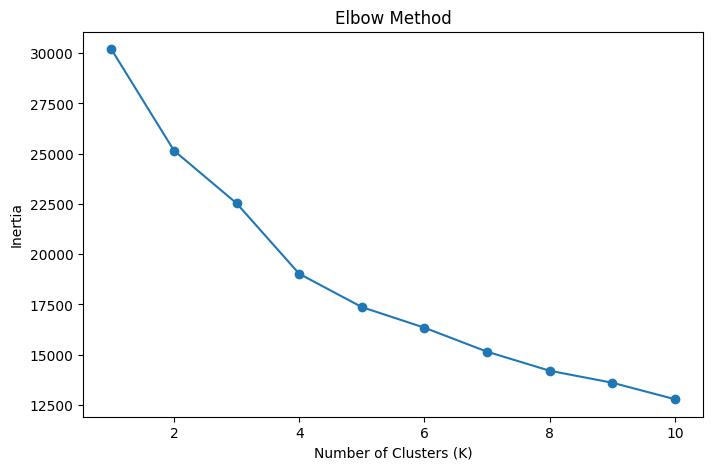

In [55]:
plt.figure(figsize=(8,5))

plt.plot(K, inertia, marker='o')

plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.title("Elbow Method")

plt.show()

In [60]:
df["Cluster"].value_counts()


Cluster
0    1461
2    1207
1    1194
3     452
Name: count, dtype: int64

In [64]:
cluster_summary = df.groupby("Cluster").agg({
    "credit_limit":"mean",
    "num_cards_issued":"mean",
    "account_age":"mean",
    "pin_age":"mean",
    "has_chip":"mean",
    "card_type":"mean",
    "card_on_dark_web":"mean"
})

cluster_summary

,credit_limit,num_cards_issued,account_age,pin_age,has_chip,card_type,card_on_dark_web
Cluster,,,,,,,
0,8067.162218,1.514716,14.993840,7.838467,1.000000,1.000000,0.0
1,16759.567002,2.017588,15.268007,7.994137,1.000000,0.009213,0.0
2,20793.791218,1.004971,14.458989,7.867440,0.999171,0.003314,0.0
3,14200.752212,1.475664,14.942478,8.305310,0.000000,0.382743,0.0


In [66]:
df.to_csv("../data/clustered_data.csv", index=False)

In [67]:
import joblib

joblib.dump(kmeans, "../models/kmeans_model.pkl")
joblib.dump(scaler, "../models/scaler.pkl")

print("Model saved successfully.")

Model saved successfully.
